--- Datasetning dastlabki 5 qatori ---
   AI_Asoslari  Differensial_Tenglamalar  Kiberxavfsizlik  \
0           78                        53               46   
1           91                        62               98   
2           68                        99               90   
3           54                        96               61   
4           82                        79               67   

   Kompyuter_Injeneringi  Ehtimollar_Nazariyasi  Final_Score  
0                     72                     46         59.9  
1                     48                     42         71.1  
2                     99                     56         82.9  
3                     98                     72         76.4  
4                     45                     87         72.4  


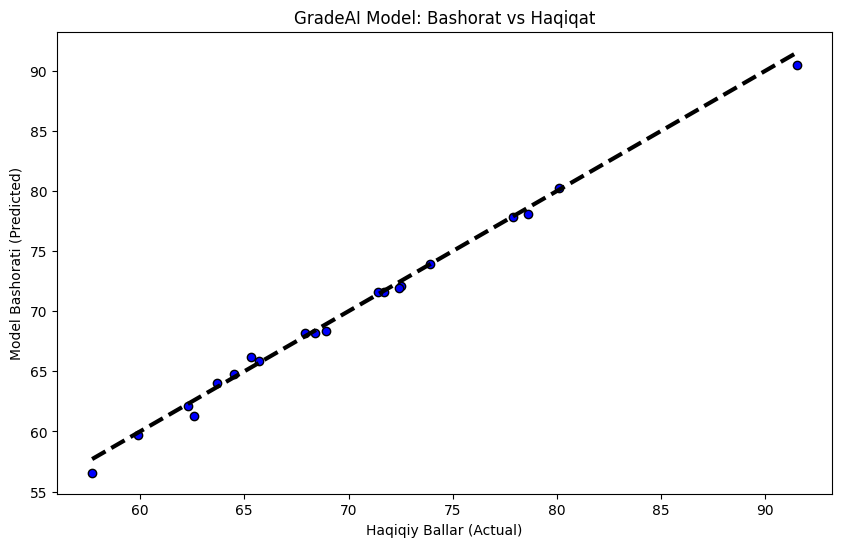


--- Model Baholash Metrikalari ---
Mean Absolute Error (MAE): 0.4182
Mean Squared Error (MSE): 0.3060
R-Squared (R2 Score): 0.9950


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# 1. DATASET YARATISH (100 ta talaba ma'lumoti)
np.random.seed(42) # Natijalar har doim bir xil chiqishi uchun
n_students = 100

data = {
    'AI_Asoslari': np.random.randint(40, 100, n_students),
    'Differensial_Tenglamalar': np.random.randint(40, 100, n_students),
    'Kiberxavfsizlik': np.random.randint(40, 100, n_students),
    'Kompyuter_Injeneringi': np.random.randint(40, 100, n_students),
    'Ehtimollar_Nazariyasi': np.random.randint(40, 100, n_students)
}

df = pd.DataFrame(data)

# Maqsadli qiymat (Final Score) hisoblash - Haqiqiy bog'liqlik yaratamiz
# GradeAI formulasi bo'yicha:
df['Final_Score'] = (
    df['AI_Asoslari'] * 0.22 +
    df['Differensial_Tenglamalar'] * 0.20 +
    df['Kiberxavfsizlik'] * 0.20 +
    df['Kompyuter_Injeneringi'] * 0.20 +
    df['Ehtimollar_Nazariyasi'] * 0.18 +
    np.random.normal(0, 0.5, n_students) # Ozgina shovqin (noise) haqiqiylik uchun
).round(1)

print("--- Datasetning dastlabki 5 qatori ---")
print(df.head())

# 2. MODELNI O'QITISHGA TAYYORLASH
X = df.drop('Final_Score', axis=1) # Kiruvchi fanlar
y = df['Final_Score']              # Bashorat qilinuvchi natija

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. MODEL QURISH (Linear Regression)
model = LinearRegression()
model.fit(X_train, y_train)

# 4. BASHORAT QILISH VA BAHOLASH
predictions = model.predict(X_test)

mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, predictions)

# 5. NATIJALARNI VISUALIZATSIYA QILISH (Word uchun Screen oling)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, color='blue', edgecolors=(0, 0, 0))
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3)
plt.xlabel('Haqiqiy Ballar (Actual)')
plt.ylabel('Model Bashorati (Predicted)')
plt.title('GradeAI Model: Bashorat vs Haqiqat')
plt.show()

# Baholash metrikalarini chiqarish
print(f"\n--- Model Baholash Metrikalari ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-Squared (R2 Score): {r2:.4f}")